# 🛍️ Análisis y Predicción de Ventas en un E-commerce Brasileño 🇧🇷

**Autor:** Alejandro Javier Contreras Olate

**Objetivo:** Analizar datos de un e-commerce brasileño para extraer insights y construir un modelo de Machine Learning que prediga el precio de los productos.

---

## 1. Importación de Librerías

Cargamos todas las librerías que necesitaremos para el análisis, visualización y modelado.

In [3]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [4]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from data_preprocessing import load_and_preprocess_data

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Carga de Datos

Cargamos los diferentes datasets. Los datos provienen del [dataset público de Olist en Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce).

In [8]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")
geolocation_cleaned = pd.read_csv("../data/geolocation_cleaned.csv")

## 3. Análisis Exploratorio de Datos (EDA)

Exploraremos los datos para entender tendencias, comportamiento de clientes y características de productos.

### 3.1. Pedidos por Estado

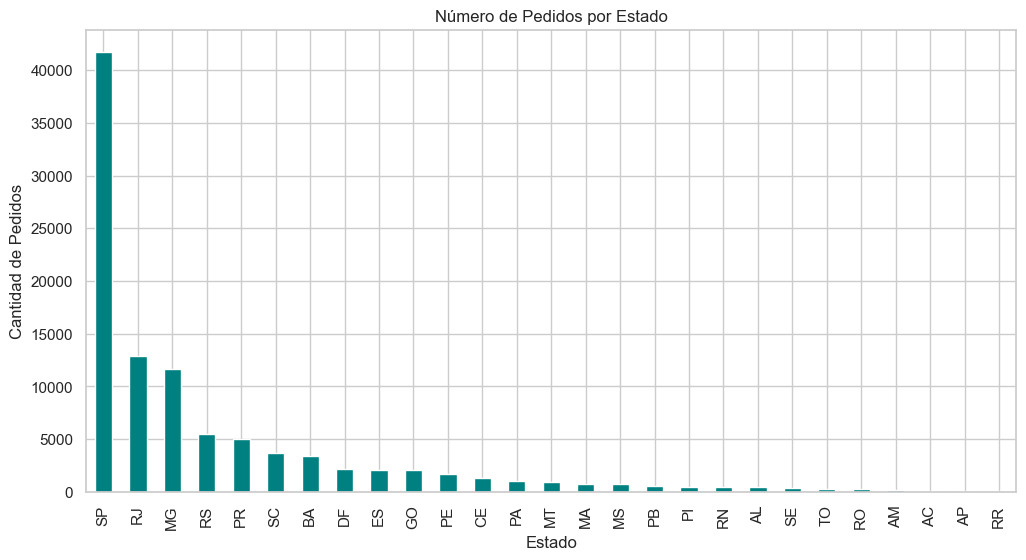

In [9]:
orders_by_state = orders.merge(customers, on="customer_id")[
    "customer_state"
].value_counts()
orders_by_state.plot(kind="bar", color="teal")
plt.title("Número de Pedidos por Estado")
plt.xlabel("Estado")
plt.ylabel("Cantidad de Pedidos")
plt.show()

**Observación:** El estado de São Paulo (SP) concentra la gran mayoría de los pedidos.

### 3.2. Categorías de Productos Más Vendidas

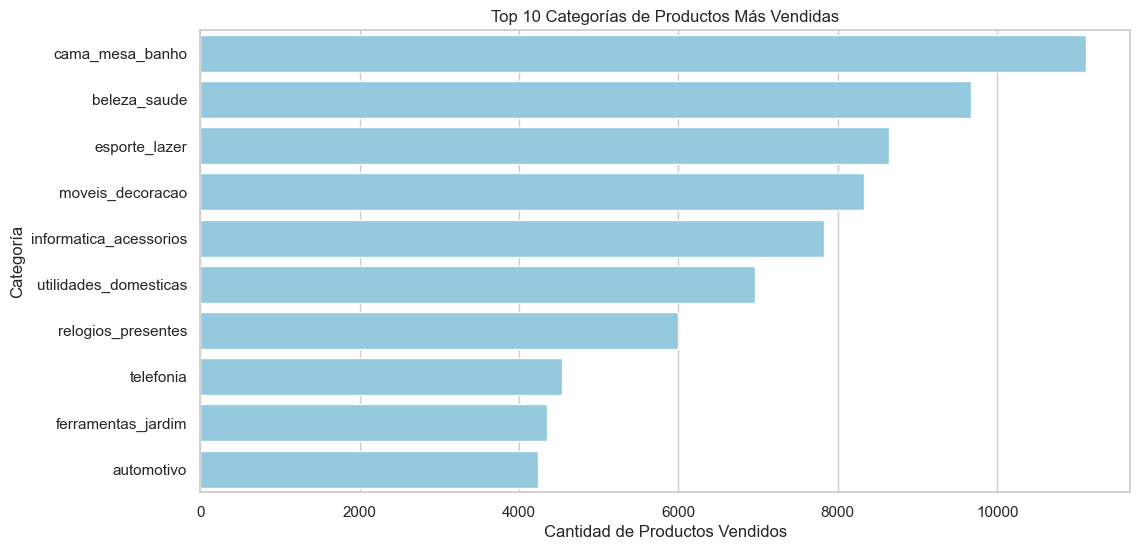

In [10]:
items_products = pd.merge(order_items, products, on="product_id")
top_categories = items_products["product_category_name"].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, color="skyblue")
plt.title("Top 10 Categorías de Productos Más Vendidas")
plt.xlabel("Cantidad de Productos Vendidos")
plt.ylabel("Categoría")
plt.show()

**Observación:** La categoría `cama_mesa_banho` es la más popular.

### 3.3. Métodos de Pago Más Utilizados

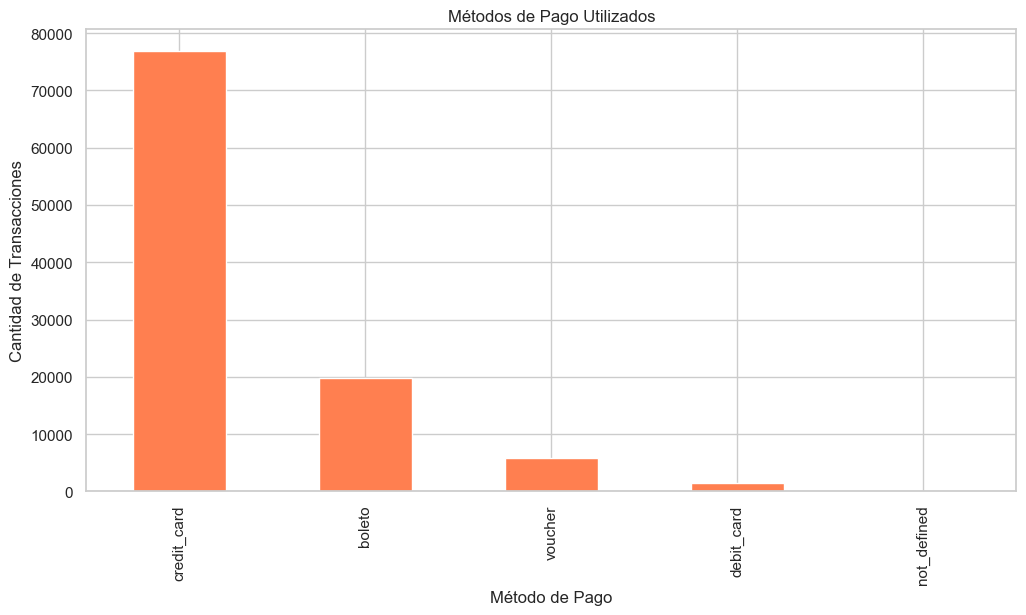

In [11]:
payment_types = payments["payment_type"].value_counts()
payment_types.plot(kind="bar", color="coral")
plt.title("Métodos de Pago Utilizados")
plt.xlabel("Método de Pago")
plt.ylabel("Cantidad de Transacciones")
plt.show()

**Observación:** La tarjeta de crédito es el método de pago preferido.

### 3.4. Distribución de las Puntuaciones de Reviews

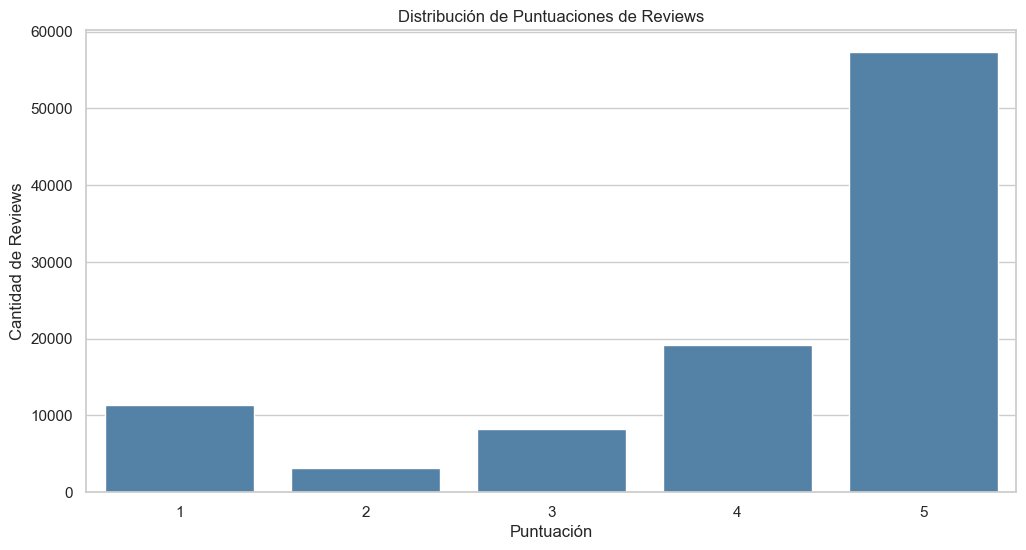

In [12]:
sns.countplot(x="review_score", data=reviews, color="steelblue")
plt.title("Distribución de Puntuaciones de Reviews")
plt.xlabel("Puntuación")
plt.ylabel("Cantidad de Reviews")
plt.show()

**Observación:** La mayoría de los clientes dejan reviews positivas (4 y 5 estrellas).

## 4. Preparación de Datos y Feature Engineering

Uniremos los datos y crearemos las variables (features) para entrenar el modelo.

In [13]:
# Llamamos a la función de preprocesamiento para crear el dataframe final
df = load_and_preprocess_data(
    order_items, products, reviews, orders, customers, sellers, geolocation_cleaned
)

# Mostramos las primeras filas para verificar
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,seller_state,customer_lat,customer_lng,seller_lat,seller_lng,month,category_encoded,seller_order_count,delivery_time_days,distance_km
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,SP,-21.762775,-41.309633,-22.496953,-44.127492,9,26,151,7.0,301.504681
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,SP,-20.220527,-50.903424,-23.565096,-46.518565,5,63,143,16.0,585.563937
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,MG,-19.870305,-44.593326,-22.262584,-46.171124,1,54,14,7.0,312.343511
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,SP,-23.089925,-46.611654,-20.553624,-47.387359,8,62,16,6.0,293.168420
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,PR,-23.243402,-46.827614,-22.929384,-53.135873,2,40,29,25.0,646.163463


## 5. Modelado y Predicción

### 5.1. Selección de Variables y División de Datos

In [14]:
features = [
    "order_item_id",
    "month",
    "category_encoded",
    "freight_value",
    "seller_order_count",
    "review_score",
    "delivery_time_days",
    "distance_km",
]
target = "price"
X = df[features].copy()
y = df[target].copy()
X.dropna(inplace=True)
y = y[X.index]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")

Entrenamiento: (90651, 8)
Prueba: (22663, 8)


### 5.2. Modelo Base: Regresión Lineal

In [15]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Regresión Lineal - R² Score: {r2_lr:.2f}")

Regresión Lineal - R² Score: 0.20


### 5.3. Modelo Avanzado: Random Forest con Pipeline y GridSearchCV

In [16]:
pipeline = Pipeline(
    [("scaler", StandardScaler()), ("rf", RandomForestRegressor(random_state=42))]
)
param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [10, 20],
    "rf__min_samples_split": [2, 5],
}
grid_search = GridSearchCV(
    pipeline, param_grid, cv=3, scoring="r2", n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'rf__max_depth': [10, 20], 'rf__min_samples_split': [2, 5], 'rf__n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


## 6. Evaluación del Modelo Final

In [17]:
print(f"Mejores parámetros: {grid_search.best_params_}")
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)
r2_final = r2_score(y_test, y_pred_final)
print(f"Modelo Final - R² Score: {r2_final:.2f}")

Mejores parámetros: {'rf__max_depth': 20, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Modelo Final - R² Score: 0.53
Modelo Final - R² Score: 0.53


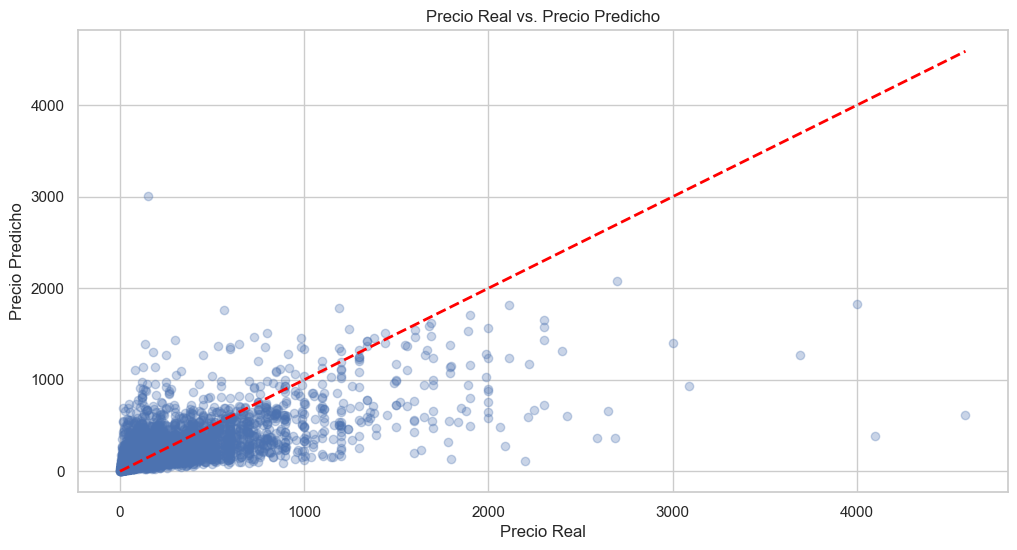

In [18]:
plt.scatter(y_test, y_pred_final, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--",
    color="red",
    linewidth=2,
)
plt.title("Precio Real vs. Precio Predicho")
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.show()

## 7. Exportación del Modelo

In [19]:
joblib.dump(best_model, "modelo_ventas_rf.pkl")
print("Modelo final guardado como modelo_ventas_rf.pkl")

Modelo final guardado como modelo_ventas_rf.pkl


## 8. Conclusiones y Aplicación de Negocio

### Conclusiones Técnicas
- El análisis exploratorio reveló una fuerte concentración de ventas en São Paulo.
- Un modelo Random Forest (R² ≈ 0.54) superó significativamente a la Regresión Lineal (R² ≈ 0.19).

### Aplicación de Negocio
1. **Estrategia de Precios Dinámica:** Sugerir precios para productos nuevos.
2. **Detección de Anomalías:** Identificar precios inusualmente altos o bajos.
3. **Optimización de Envíos:** Simular cómo los costos de envío impactan el precio final.